In [1]:
import sys
!{sys.executable} -m pip install python_speech_features

  Preparing metadata (setup.py) ... done
  Created wheel for python_speech_features: filename=python_speech_features-0.6-py3-none-any.whl size=5870 sha256=e03187160d8c0fd07e8f596a943692c46a30989abea791bd0faafe6743a41927
  Stored in directory: /Users/vikasshukla/Library/Caches/pip/wheels/37/01/19/e6c69a32684ab7b2e3ea4985a571d810cf055c72600e7f9f17
Successfully built python_speech_features

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: /Users/vikasshukla/.pyenv/versions/3.11.6/bin/python -m pip install --upgrade pip


MFCC feature shape: (299, 13)
Filter bank feature shape: (299, 26)


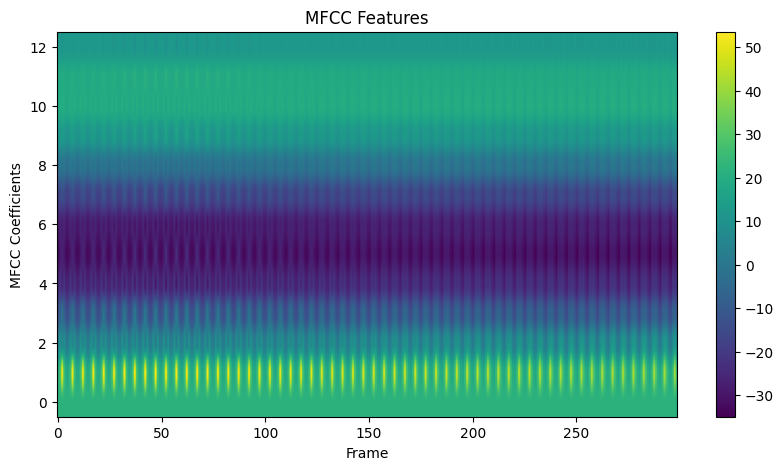

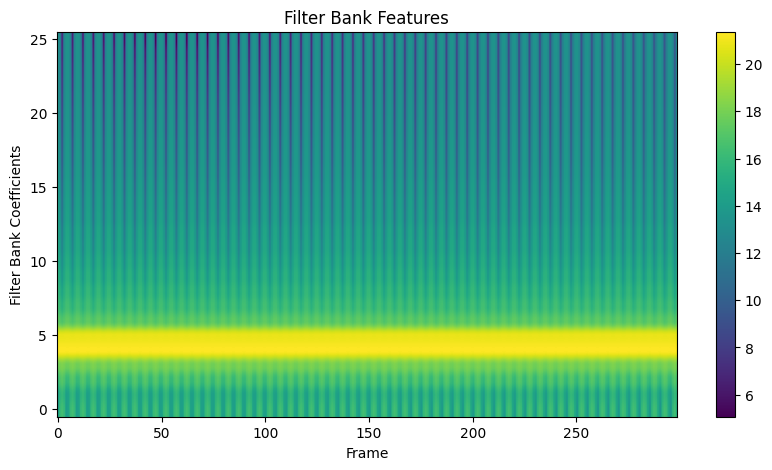

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import write, read
from python_speech_features import mfcc, logfbank

# Generate sample speech-like audio signal
sampling_freq = 16000
duration = 3
frequency = 440

time_axis = np.linspace(0, duration, int(sampling_freq * duration))

signal = np.sin(2 * np.pi * frequency * time_axis)

# Save audio file
write(
    "speech_sample.wav",
    sampling_freq,
    (signal * 32767).astype(np.int16)
)

# Read audio file
sampling_freq, audio_signal = read("speech_sample.wav")

# Extract MFCC features
mfcc_features = mfcc(audio_signal, sampling_freq)

# Extract filter bank features
filterbank_features = logfbank(audio_signal, sampling_freq)

print("MFCC feature shape:", mfcc_features.shape)
print("Filter bank feature shape:", filterbank_features.shape)

# Plot MFCC features
plt.figure(figsize=(10, 5))
plt.imshow(mfcc_features.T, aspect="auto", origin="lower")
plt.title("MFCC Features")
plt.xlabel("Frame")
plt.ylabel("MFCC Coefficients")
plt.colorbar()
plt.show()

# Plot filter bank features
plt.figure(figsize=(10, 5))
plt.imshow(filterbank_features.T, aspect="auto", origin="lower")
plt.title("Filter Bank Features")
plt.xlabel("Frame")
plt.ylabel("Filter Bank Coefficients")
plt.colorbar()
plt.show()